# Potent / Null Subspace Analysis
Iteratively remove direction or disturbance axes from neural population activity
and measure how much of each signal is preserved vs destroyed.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../../')


In [2]:
import glob
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, cross_validate, StratifiedKFold

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin
from tools.viz.rc_style import rc_context_talk


from tqdm import tqdm
import pickle

from joblib import Parallel, delayed

import numpy as np

In [3]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]

# Number of PCs to use per area
pc_dict = {"MOp": 30, "SSp": 25, "CP": 30, "VAL": 50}

In [4]:
td, _ = dsp.load_and_process_session(SESSIONS[0], std=0.03)
perturb_td = pyal.restrict_to_interval(
    td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300
)
perturb_td = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)
td_drop    = dsp.drop_trials_sem_crosses_zero(perturb_td, std=False)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)
Skipped 40 trials
Otsu immobility threshold: 2.9536
Dropped 48 of 333 rows (14.41%).
  drop_trials_sem_crosses_zero: by SEM: 221  |  by value: 270  |  kept: 221/270 (81.9%)


In [5]:
def get_lda_axes(X_epoch, labels):
    """Fit LDA and return orthonormal discriminant axes (n_features, n_classes-1)."""
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_epoch, labels)
    Q, _ = np.linalg.qr(lda.scalings_)
    return Q


def get_ridge_axis(X_epoch, y, alpha=0.01):
    """Fit Ridge and return the normalised weight vector as a (n_features, 1) column."""
    reg = Ridge(alpha)
    reg.fit(X_epoch, y)
    w = reg.coef_.ravel()
    return (w / np.linalg.norm(w))[:, None]

def get_ridge_basis(X_epoch, y, alpha=0.01):
    """Fit Ridge and return orthonormalised weight vector via QR.
    Same interface as get_ridge_axis but uses QR instead of manual normalisation.
    Returns (n_features, 1) orthonormal column, or zeros if weight is degenerate.
    """
    reg = Ridge(alpha, solver='svd')
    reg.fit(X_epoch, y)
    w = reg.coef_.ravel()[:, None]  # (n_features, 1)
    basis = scipy.linalg.orth(w)    # (n_features, 1) or (n_features, 0) if near-zero
    if basis.shape[1] == 0:
        return np.zeros((X_epoch.shape[1], 1))
    return basis


def norm_residual(scores, lb):
    """Normalise final iteration score: 0 = destroyed, 1 = preserved."""
    s0  = np.mean(scores[0])
    sf  = np.mean(scores[-1])
    lb0 = np.mean(lb[0]) if isinstance(lb, list) else lb
    denom = s0 - lb0
    if denom < 1e-9:
        return np.nan
    return (sf - lb0) / denom


def norm_residual_folds(scores, lb):
    """Per-fold normalised residuals — normalise by mean iter-0 and mean lb."""
    s0_folds = np.array(scores[0])
    sf_folds = np.array(scores[-1])
    lb0_mean = np.mean(lb[0]) if isinstance(lb, list) else lb
    denom    = np.mean(s0_folds) - lb0_mean
    if denom < 1e-9:
        return np.full(len(s0_folds), np.nan)
    return (sf_folds - lb0_mean) / denom


# Example single session

In [29]:
# ── Rolling-window direction removal ─────────────────────────────────────────
# For each window of win_size bins:
#   1. Epoch = mean over window → (n_trials, N)
#   2. Iteratively fit LDA → direction axes, compute null projection (n_iter times)
#   3. CV-decode direction (train-null/test-null) and disturbance (train-null/test-null)
#      from full and null epoch
# Gives a time-resolved picture of direction/disturbance separation.

area      = 'MOp'
win_size  = 20       # bins (30 ms)
step      = 1       # stride in bins
t_start   = 125     # bin index start  (relative to trial start, not sol_on)
t_end     = 400     # bin index end
n_iter    = 3       # number of iterative direction-axis removals
y_dir   = np.array(td_drop.values_Sol_direction.values.tolist())
y_dist  = td_drop.disturb_sum.values.astype(float)
rng     = np.random.default_rng(42)
n_splits = 4
shuffle = True
cv_dir = StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=42)
cv_dist = KFold(n_splits=n_splits, shuffle=shuffle, random_state=42)
alpha_ridge = 0.01

_, _counts = np.unique(y_dir, return_counts=True)
chance  = _counts.max() / _counts.sum()   # majority class probability
pc_dict = {
    "MOp": 30,
    "SSp": 25,
    "CP": 30,
    "VAL": 50,
    "MOs": 30
}
X_full_a  = np.stack(td_drop[f'{area}_rates_pca'].values)[:, :, :pc_dict[area]]
X_rates_a = np.concatenate(td_drop[f'{area}_rates'].values)
var_pop_a = np.trace(np.cov(X_rates_a.T))

y_shuf_t  = rng.permutation(y_dist)

win_starts = np.arange(t_start, t_end - win_size + 1, step)
times_s    = (win_starts + win_size - 200) * 0.01  # seconds re sol_on

dir_full_m,  dir_full_s  = [], []
dir_null_m,  dir_null_s  = [], []
dist_full_m, dist_full_s = [], []
dist_null_m, dist_null_s = [], []
dist_lb_m,   dist_lb_s   = [], []
# per-fold scores at each time window
dir_full_folds  = []
dir_null_folds  = []
dist_full_folds = []
dist_null_folds = []
var_frac_pca = []
var_frac_pop = []

for t in win_starts:
    X_win  = X_full_a[:, t:t+win_size, :].mean(axis=1)   # (n_trials, N)

    # iterative direction removal
    X_null = X_win.copy()
    for _ in range(n_iter):
        axes   = get_lda_axes(X_null, y_dir)
        P_null = np.eye(pc_dict[area]) - axes @ axes.T
        X_null = X_null @ P_null

    # variance diagnostics
    var_win    = np.trace(np.cov(X_win.T))
    var_null_w = np.trace(np.cov(X_null.T))
    var_frac_pca.append(var_null_w / var_win)
    var_frac_pop.append(var_null_w / var_pop_a)

    # direction: train-null / test-null
    dir_f, dir_n = [], []
    for tr, te in cv_dir.split(X_win, y_dir):
        clf_f = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
        clf_f.fit(X_win[tr],  y_dir[tr])
        dir_f.append(clf_f.score(X_win[te],  y_dir[te]))
        clf_n = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
        clf_n.fit(X_null[tr], y_dir[tr])
        dir_n.append(clf_n.score(X_null[te], y_dir[te]))

    # disturbance: train-null / test-null
    dist_f, dist_n, dist_lb = [], [], []
    for tr, te in cv_dist.split(X_win):
        reg_f = Ridge(alpha_ridge); reg_f.fit(X_win[tr],  y_dist[tr])
        reg_n = Ridge(alpha_ridge); reg_n.fit(X_null[tr], y_dist[tr])
        dist_f.append( r2_score(y_dist[te],   reg_f.predict(X_win[te])))
        dist_n.append( r2_score(y_dist[te],   reg_n.predict(X_null[te])))
        dist_lb.append(r2_score(y_shuf_t[te], reg_f.predict(X_win[te])))

    dir_full_m.append(np.mean(dir_f));   dir_full_s.append(np.std(dir_f))
    dir_null_m.append(np.mean(dir_n));   dir_null_s.append(np.std(dir_n))
    dist_full_m.append(np.mean(dist_f)); dist_full_s.append(np.std(dist_f))
    dist_null_m.append(np.mean(dist_n)); dist_null_s.append(np.std(dist_n))
    dist_lb_m.append(np.mean(dist_lb));  dist_lb_s.append(np.std(dist_lb))
    dir_full_folds.append(dir_f)
    dir_null_folds.append(dir_n)
    dist_full_folds.append(dist_f)
    dist_null_folds.append(dist_n)

dir_full_m  = np.array(dir_full_m);  dir_full_s  = np.array(dir_full_s)
dir_null_m  = np.array(dir_null_m);  dir_null_s  = np.array(dir_null_s)
dist_full_m = np.array(dist_full_m); dist_full_s = np.array(dist_full_s)
dist_null_m = np.array(dist_null_m); dist_null_s = np.array(dist_null_s)
dist_lb_m   = np.array(dist_lb_m);   dist_lb_s   = np.array(dist_lb_s)
var_frac_pca = np.array(var_frac_pca)
var_frac_pop = np.array(var_frac_pop)

# ── Save results ──────────────────────────────────────────────────────────────
rolling_results = {
    'area':             area,
    'win_size':         win_size,
    'step':             step,
    'n_iter':           n_iter,
    'times_s':          times_s,
    'chance':           chance,
    'dir_full_m':       dir_full_m,   'dir_full_s':   dir_full_s,
    'dir_null_m':       dir_null_m,   'dir_null_s':   dir_null_s,
    'dist_full_m':      dist_full_m,  'dist_full_s':  dist_full_s,
    'dist_null_m':      dist_null_m,  'dist_null_s':  dist_null_s,
    'dist_lb_m':        dist_lb_m,    'dist_lb_s':    dist_lb_s,
    'dir_full_folds':   dir_full_folds,
    'dir_null_folds':   dir_null_folds,
    'dist_full_folds':  dist_full_folds,
    'dist_null_folds':  dist_null_folds,
    'var_frac_pca':     var_frac_pca,
    'var_frac_pop':     var_frac_pop,
}

print(f'Peak direction full:  {dir_full_m.max():.3f} at t={times_s[dir_full_m.argmax()]:.2f}s')
print(f'Peak disturbance full: {dist_full_m.max():.3f} at t={times_s[dist_full_m.argmax()]:.2f}s')
print(f'Min var remaining: {var_frac_pca.min()*100:.1f}% of window / {var_frac_pop.min()*100:.1f}% of pop')

Peak direction full:  0.519 at t=0.23s
Peak disturbance full: 0.459 at t=0.36s
Min var remaining: 34.9% of window / 11.7% of pop


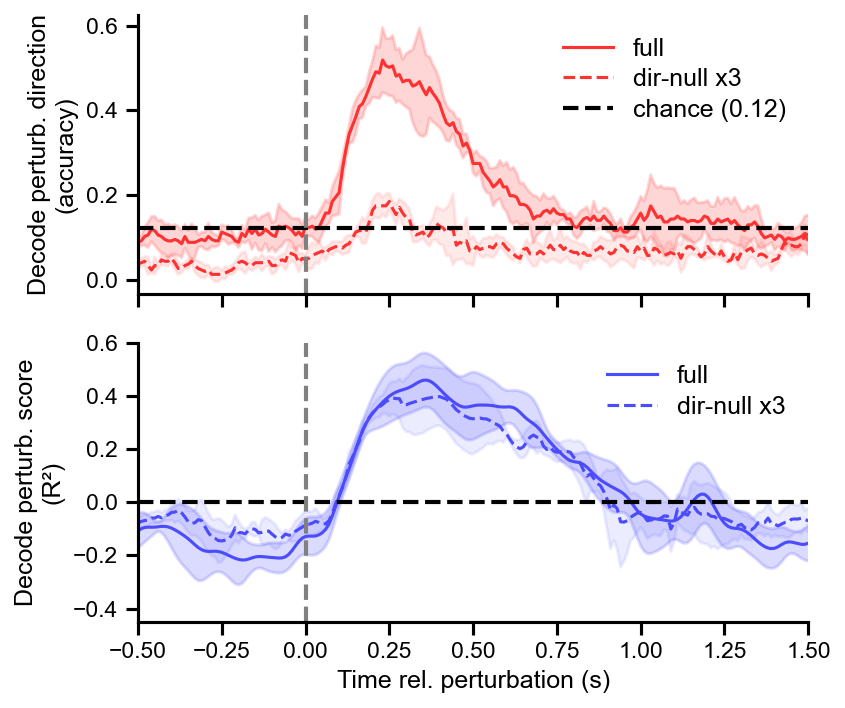

In [35]:
from tools.viz.rc_style import rc_context_talk

# ── Plot ──────────────────────────────────────────────────────────────────────
bwr   = mpl.colormaps['bwr']
C_DIR = bwr(0.9)   # red from bwr
C_DIST = bwr(0.15)   # red from bwr

with rc_context_talk():
    fig, axs = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

    # Direction
    axs[0].fill_between(times_s, dir_full_m - dir_full_s, dir_full_m + dir_full_s,
                        color=C_DIR, alpha=0.2)
    axs[0].fill_between(times_s, dir_null_m - dir_null_s, dir_null_m + dir_null_s,
                        color=C_DIR, alpha=0.1)
    axs[0].plot(times_s, dir_full_m, color=C_DIR,          lw=1.5, label='full')
    axs[0].plot(times_s, dir_null_m, color=C_DIR, ls='--', lw=1.5, label=f'dir-null x{n_iter}')
    axs[0].axhline(chance, color='k', ls='dashed', label=f'chance ({chance:.2f})')
    axs[0].axvline(0, color='grey', linestyle='dashed')
    axs[0].set_ylabel('Decode perturb. direction\n(accuracy)')
    # axs[0].set_title(f'{area} -- direction decoding')
    axs[0].legend()

    # Disturbance
    axs[1].fill_between(times_s, dist_full_m - dist_full_s, dist_full_m + dist_full_s,
                        color=C_DIST, alpha=0.2)
    axs[1].fill_between(times_s, dist_null_m - dist_null_s, dist_null_m + dist_null_s,
                        color=C_DIST, alpha=0.1)
    axs[1].plot(times_s, dist_full_m, color=C_DIST,          lw=1.5, label='full')
    axs[1].plot(times_s, dist_null_m, color=C_DIST, ls='--', lw=1.5, label=f'dir-null x{n_iter}')
    # axs[1].fill_between(times_s, dist_lb_m - dist_lb_s, dist_lb_m + dist_lb_s,
    #                     color=C_DIST, alpha=0.15)
    # axs[1].plot(times_s, dist_lb_m, color=C_DIST, ls=':', label='lower bound')
    axs[1].axhline(0, color='k', ls='--')
    axs[1].axvline(0, color='grey', linestyle='dashed')
    axs[1].set_ylabel('Decode perturb. score\n(R²)')
    # axs[1].set_title('Disturbance decoding')
    axs[1].set_xlabel('Time rel. perturbation (s)')
    axs[1].legend()
    axs[1].set_xlim(-0.5, 1.5)
    axs[1].set_ylim(-0.45, 0.6)

    # plt.suptitle(f'{area} -- rolling-window direction removal (win={win_size} bins, step={step} bins, n_iter={n_iter})', fontsize=11)
    plt.tight_layout()
    plt.show()
    fig.savefig('../../results/pdfs/example_orthogonal_mop_time_1.svg', bbox_inches='tight')



In [6]:
# ── Rolling-window disturbance removal ───────────────────────────────────────
# For each window of win_size bins:
#   1. Epoch = mean over window → (n_trials, N)
#   2. Iteratively fit Ridge → disturbance axis, compute null projection (n_iter_dist times)
#   3. CV-decode direction and disturbance from full and null epoch
# Shows how much direction info is preserved after disturbance removal.

n_iter_dist = 5   # number of iterative disturbance-axis removals
t_start   = 125     # bin index start  (relative to trial start, not sol_on)
t_end     = 400     # bin index end
win_size = 20
# Reuse setup from previous cell (area, win_size, step, t_start, t_end,
# X_full_a, y_dir, y_dist, y_shuf_t, cv_dir, cv_dist, alpha_ridge, pc_dict, times_s, win_r2_score
# n_splits = 4
dir_full_dr_m,  dir_full_dr_s  = [], []
dir_null_dr_m,  dir_null_dr_s  = [], []
dist_full_dr_m, dist_full_dr_s = [], []
dist_null_dr_m, dist_null_dr_s = [], []
dist_lb_dr_m,   dist_lb_dr_s   = [], []
dir_full_dr_folds  = []
dir_null_dr_folds  = []
dist_full_dr_folds = []
dist_null_dr_folds = []
# cv_dir = StratifiedKFold(n_splits=n_splits, shuffle=False)
# cv_dist = KFold(n_splits=n_splits, shuffle=False)
for t in tqdm(win_starts):
    X_win  = X_full_a[:, t:t+win_size, :].mean(axis=1)   # (n_trials, N)

    # iterative disturbance removal (only in 0–1 s post-perturbation window)
    t_s = (t + win_size - 200) * 0.01  # seconds re sol_on
    X_null = X_win.copy()

    for _ in range(n_iter_dist):
        ax     = get_ridge_axis(X_null, y_dist, alpha=alpha_ridge)
        X_null = X_null @ (np.eye(pc_dict[area]) - ax @ ax.T)

    # direction decoding: full vs null
    dir_f, dir_n = [], []
    for tr, te in cv_dir.split(X_win, y_dir):
        clf_f = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
        clf_f.fit(X_win[tr],  y_dir[tr])
        dir_f.append(clf_f.score(X_win[te],  y_dir[te]))
        clf_n = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
        clf_n.fit(X_null[tr], y_dir[tr])
        dir_n.append(clf_n.score(X_null[te], y_dir[te]))

    # disturbance decoding: full vs null
    dist_f, dist_n, dist_lb = [], [], []
    for tr, te in cv_dist.split(X_win):
        reg_f = Ridge(alpha_ridge, solver='svd'); reg_f.fit(X_win[tr],  y_dist[tr])
        reg_n = Ridge(alpha_ridge, solver='svd'); reg_n.fit(X_null[tr], y_dist[tr])
        dist_f.append( r2_score(y_dist[te],   reg_f.predict(X_win[te])))
        dist_n.append( r2_score(y_dist[te],   reg_n.predict(X_null[te])))
        dist_lb.append(r2_score(y_shuf_t[te], reg_f.predict(X_win[te])))

    dir_full_dr_m.append(np.mean(dir_f));   dir_full_dr_s.append(np.std(dir_f))
    dir_null_dr_m.append(np.mean(dir_n));   dir_null_dr_s.append(np.std(dir_n))
    dist_full_dr_m.append(np.mean(dist_f)); dist_full_dr_s.append(np.std(dist_f))
    dist_null_dr_m.append(np.mean(dist_n)); dist_null_dr_s.append(np.std(dist_n))
    dist_lb_dr_m.append(np.mean(dist_lb));  dist_lb_dr_s.append(np.std(dist_lb))
    dir_full_dr_folds.append(dir_f)
    dir_null_dr_folds.append(dir_n)
    dist_full_dr_folds.append(dist_f)
    dist_null_dr_folds.append(dist_n)

dir_full_dr_m  = np.array(dir_full_dr_m);  dir_full_dr_s  = np.array(dir_full_dr_s)
dir_null_dr_m  = np.array(dir_null_dr_m);  dir_null_dr_s  = np.array(dir_null_dr_s)
dist_full_dr_m = np.array(dist_full_dr_m); dist_full_dr_s = np.array(dist_full_dr_s)
dist_null_dr_m = np.array(dist_null_dr_m); dist_null_dr_s = np.array(dist_null_dr_s)
dist_lb_dr_m   = np.array(dist_lb_dr_m);   dist_lb_dr_s   = np.array(dist_lb_dr_s)

rolling_dist_rem_results = dict(
    area=area, win_size=win_size, step=step, n_iter=n_iter_dist,
    times_s=times_s, chance=chance,
    dir_full_m=dir_full_dr_m,   dir_full_s=dir_full_dr_s,
    dir_null_m=dir_null_dr_m,   dir_null_s=dir_null_dr_s,
    dist_full_m=dist_full_dr_m, dist_full_s=dist_full_dr_s,
    dist_null_m=dist_null_dr_m, dist_null_s=dist_null_dr_s,
    dist_lb_m=dist_lb_dr_m,     dist_lb_s=dist_lb_dr_s,
    dir_full_folds=dir_full_dr_folds,   dir_null_folds=dir_null_dr_folds,
    dist_full_folds=dist_full_dr_folds, dist_null_folds=dist_null_dr_folds,
)

print(f'Peak direction full:   {dir_full_dr_m.max():.3f} at t={times_s[dir_full_dr_m.argmax()]:.2f}s')
print(f'Peak direction null:   {dir_null_dr_m.max():.3f} at t={times_s[dir_null_dr_m.argmax()]:.2f}s')
print(f'Peak disturbance full: {dist_full_dr_m.max():.3f} at t={times_s[dist_full_dr_m.argmax()]:.2f}s')
print(f'Peak disturbance null: {dist_null_dr_m.max():.3f} at t={times_s[dist_null_dr_m.argmax()]:.2f}s')


NameError: name 'win_starts' is not defined

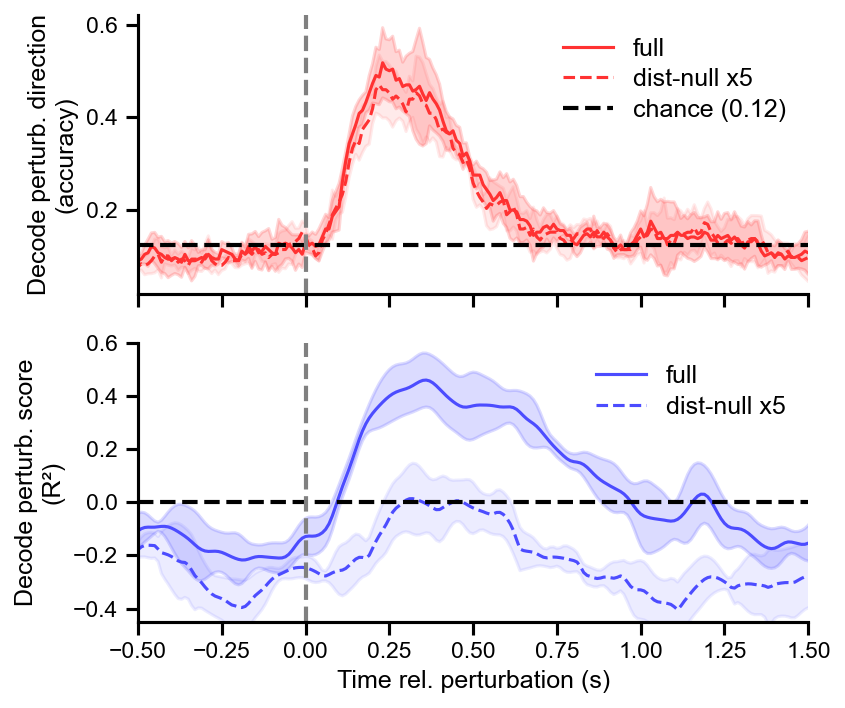

In [65]:
# ── Plot: rolling-window disturbance removal ──────────────────────────────────
r = rolling_dist_rem_results

with rc_context_talk():
    fig, axs = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

    # Direction (expect ~preserved after disturbance removal)
    axs[0].fill_between(r['times_s'],
                        r['dir_full_m'] - r['dir_full_s'],
                        r['dir_full_m'] + r['dir_full_s'], color=C_DIR, alpha=0.2)
    axs[0].fill_between(r['times_s'],
                        r['dir_null_m'] - r['dir_null_s'],
                        r['dir_null_m'] + r['dir_null_s'], color=C_DIR, alpha=0.1)
    axs[0].plot(r['times_s'], r['dir_full_m'], color=C_DIR,          lw=1.5, label='full')
    axs[0].plot(r['times_s'], r['dir_null_m'], color=C_DIR, ls='--', lw=1.5,
                label=f'dist-null x{r["n_iter"]}')
    axs[0].axhline(r['chance'], color='k', ls='dashed', label=f'chance ({r["chance"]:.2f})')
    axs[0].axvline(0, color='grey', ls='dashed')
    axs[0].set_ylabel('Decode perturb. direction\n(accuracy)')

    axs[0].legend()

    # Disturbance (expect ~destroyed after disturbance removal)
    axs[1].fill_between(r['times_s'],
                        r['dist_full_m'] - r['dist_full_s'],
                        r['dist_full_m'] + r['dist_full_s'], color=C_DIST, alpha=0.2)
    axs[1].fill_between(r['times_s'],
                        r['dist_null_m'] - r['dist_null_s'],
                        r['dist_null_m'] + r['dist_null_s'], color=C_DIST, alpha=0.1)
    axs[1].plot(r['times_s'], r['dist_full_m'], color=C_DIST,          lw=1.5, label='full')
    axs[1].plot(r['times_s'], r['dist_null_m'], color=C_DIST, ls='--', lw=1.5,
                label=f'dist-null x{r["n_iter"]}')
    axs[1].axhline(0, color='k', ls='--')
    axs[1].set_ylabel('Decode perturb. score\n(R²)')


    # axs[1].fill_between(r['times_s'],
    #                     r['dist_lb_m'] - r['dist_lb_s'],
    #                     r['dist_lb_m'] + r['dist_lb_s'], color=C_DIST, alpha=0.15)
    # axs[1].plot(r['times_s'], r['dist_lb_m'], color=C_DIST, ls=':', label='lower bound')
    axs[1].axvline(0, color='grey', ls='dashed')
    axs[1].set_xlabel('Time rel. perturbation (s)')
    axs[1].set_xlim(-0.5, 1.5)
    axs[1].legend()
    axs[1].set_ylim(-0.45, 0.6)


    plt.tight_layout()
    plt.show()
    fig.savefig('../../results/pdfs/example_orthogonal_mop_time_2.svg', bbox_inches='tight')



In [30]:
# ── Peak ± std across CV folds ───────────────────────────────────────────────
r = rolling_results

metrics = [
    ('Direction full',    r['dir_full_m'],   r['dir_full_folds']),
    (f'Direction null x{r["n_iter"]}', r['dir_null_m'],   r['dir_null_folds']),
    ('Disturbance full',  r['dist_full_m'],  r['dist_full_folds']),
    (f'Disturbance null x{r["n_iter"]}', r['dist_null_m'], r['dist_null_folds']),
]

print(f'{"Metric":<25}  {"Peak mean":>10}  {"±std folds":>10}  {"t_peak (s)":>10}')
print('-' * 62)
for name, m, folds in metrics:
    idx      = m.argmax()
    peak_m   = m[idx]
    peak_std = np.std(folds[idx])
    t_peak   = r['times_s'][idx]
    print(f'{name:<25}  {peak_m:>10.3f}  {peak_std:>10.3f}  {t_peak:>10.2f}s')


Metric                      Peak mean  ±std folds  t_peak (s)
--------------------------------------------------------------
Direction full                  0.345       0.012        0.32s
Direction null x3               0.149       0.010        0.36s
Disturbance full                0.484       0.059        0.44s
Disturbance null x3             0.489       0.055        0.44s


## Time averaged plots

In [52]:
# ── Epoch-average iterative removal ──────────────────────────────────────────
epoch_s    = np.array([0.0, 0.5])                    # seconds re sol_on
epoch_bins = (epoch_s / 0.01 + 200).astype(int)     # bins relative to trial start
max_iter_dir  = 3   # iterations for direction removal
max_iter_dist = 4   # iterations for disturbance removal

cv_dir = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_dist = KFold(n_splits=n_splits, shuffle=True, random_state=42)

X_epoch = X_full_a[:, epoch_bins[0]:epoch_bins[1], :].mean(axis=1)  # (n_trials, N)

alpha_ridge = 10e-2

# ── Direction removal (rebuild from scratch at each step) ────────────────────
dir_rem_dir_folds  = []
dir_rem_dist_folds = []
dir_rem_lb_folds   = []

for n_rem in range(max_iter_dir + 1):
    X_d = X_epoch.copy()
    for _ in range(n_rem):
        ax  = get_lda_axes(X_d, y_dir)
        X_d = X_d @ (np.eye(pc_dict[area]) - ax @ ax.T)

    d_dir  = [LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
               .fit(X_d[tr], y_dir[tr]).score(X_d[te], y_dir[te])
               for tr, te in cv_dir.split(X_d, y_dir)]
    d_dist = [decode.custom_r2_func(y_dist[te],
                  Ridge(alpha_ridge).fit(X_d[tr], y_dist[tr]).predict(X_d[te]))
               for tr, te in cv_dist.split(X_d)]
    d_lb   = [decode.custom_r2_func(y_shuf_t[te],
                  Ridge(alpha_ridge).fit(X_d[tr], y_dist[tr]).predict(X_d[te]))
               for tr, te in cv_dist.split(X_d)]

    dir_rem_dir_folds.append(d_dir)
    dir_rem_dist_folds.append(d_dist)
    dir_rem_lb_folds.append(d_lb)

# ── Disturbance removal (incremental) ────────────────────────────────────────
dist_rem_dir_folds  = []
dist_rem_dist_folds = []
dist_rem_lb_folds   = []

X_d_curr = X_epoch.copy()

for n_rem in range(max_iter_dist + 1):
    d_dir  = [LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
               .fit(X_d_curr[tr], y_dir[tr]).score(X_d_curr[te], y_dir[te])
               for tr, te in cv_dir.split(X_d_curr, y_dir)]
    d_dist = [r2_score(y_dist[te],
                  Ridge(alpha_ridge).fit(X_d_curr[tr], y_dist[tr]).predict(X_d_curr[te]))
               for tr, te in cv_dist.split(X_d_curr)]
    d_lb   = [r2_score(y_shuf_t[te],
                  Ridge(alpha_ridge).fit(X_d_curr[tr], y_dist[tr]).predict(X_d_curr[te]))
               for tr, te in cv_dist.split(X_d_curr)]

    dist_rem_dir_folds.append(d_dir)
    dist_rem_dist_folds.append(d_dist)
    dist_rem_lb_folds.append(d_lb)

    if n_rem == 0:
        # save predictions vs actuals at first iteration (no removal)
        dist_first_pred, dist_first_true = [], []
        for tr, te in cv_dist.split(X_d_curr):
            reg = Ridge(alpha_ridge, solver='svd').fit(X_d_curr[tr], y_dist[tr])
            dist_first_pred.append(reg.predict(X_d_curr[te]))
            dist_first_true.append(y_dist[te])
        dist_first_pred = np.concatenate(dist_first_pred)
        dist_first_true = np.concatenate(dist_first_true)

    if n_rem == max_iter_dist:
        # save predictions vs actuals at final removal iteration
        dist_final_pred, dist_final_true = [], []
        for tr, te in cv_dist.split(X_d_curr):
            reg = Ridge(alpha_ridge, solver='svd').fit(X_d_curr[tr], y_dist[tr])
            dist_final_pred.append(reg.predict(X_d_curr[te]))
            dist_final_true.append(y_dist[te])
        dist_final_pred = np.concatenate(dist_final_pred)
        dist_final_true = np.concatenate(dist_final_true)

    if n_rem < max_iter_dist:
        ax       = get_ridge_axis(X_d_curr, y_dist, alpha=alpha_ridge)
        X_d_curr = X_d_curr @ (np.eye(pc_dict[area]) - ax @ ax.T)

# ── Aggregate ────────────────────────────────────────────────────────────────
iters_dir  = np.arange(max_iter_dir  + 1)
iters_dist = np.arange(max_iter_dist + 1)

dir_rem_dir_m   = np.array([np.mean(f) for f in dir_rem_dir_folds])
dir_rem_dir_s   = np.array([np.std(f)  for f in dir_rem_dir_folds])
dir_rem_dist_m  = np.array([np.mean(f) for f in dir_rem_dist_folds])
dir_rem_dist_s  = np.array([np.std(f)  for f in dir_rem_dist_folds])
dir_rem_lb_m    = np.array([np.mean(f) for f in dir_rem_lb_folds])
dir_rem_lb_s    = np.array([np.std(f)  for f in dir_rem_lb_folds])

dist_rem_dir_m  = np.array([np.mean(f) for f in dist_rem_dir_folds])
dist_rem_dir_s  = np.array([np.std(f)  for f in dist_rem_dir_folds])
dist_rem_dist_m = np.array([np.mean(f) for f in dist_rem_dist_folds])
dist_rem_dist_s = np.array([np.std(f)  for f in dist_rem_dist_folds])
dist_rem_lb_m   = np.array([np.mean(f) for f in dist_rem_lb_folds])
dist_rem_lb_s   = np.array([np.std(f)  for f in dist_rem_lb_folds])

epoch_results = dict(
    area=area, epoch_s=epoch_s,
    max_iter_dir=max_iter_dir, iters_dir=iters_dir,
    max_iter_dist=max_iter_dist, iters_dist=iters_dist,
    chance=chance,
    dir_rem_dir_m=dir_rem_dir_m,    dir_rem_dir_s=dir_rem_dir_s,
    dir_rem_dist_m=dir_rem_dist_m,  dir_rem_dist_s=dir_rem_dist_s,
    dir_rem_lb_m=dir_rem_lb_m,      dir_rem_lb_s=dir_rem_lb_s,
    dist_rem_dir_m=dist_rem_dir_m,  dist_rem_dir_s=dist_rem_dir_s,
    dist_rem_dist_m=dist_rem_dist_m, dist_rem_dist_s=dist_rem_dist_s,
    dist_rem_lb_m=dist_rem_lb_m,    dist_rem_lb_s=dist_rem_lb_s,
    dir_rem_dir_folds=dir_rem_dir_folds,
    dir_rem_dist_folds=dir_rem_dist_folds,
    dir_rem_lb_folds=dir_rem_lb_folds,
    dist_rem_dir_folds=dist_rem_dir_folds,
    dist_rem_dist_folds=dist_rem_dist_folds,
    dist_rem_lb_folds=dist_rem_lb_folds,
    dist_first_pred=dist_first_pred,
    dist_first_true=dist_first_true,
    dist_final_pred=dist_final_pred,
    dist_final_true=dist_final_true,
)

print(f'{area}  Epoch avg: {epoch_s}s')
print(f'Direction removal  → dir acc:   {[f"{v:.3f}" for v in dir_rem_dir_m]}')
print(f'Direction removal  → dist R\u00b2:   {[f"{v:.3f}" for v in dir_rem_dist_m]}')
print(f'Disturbance removal → dir acc:  {[f"{v:.3f}" for v in dist_rem_dir_m]}')
print(f'Disturbance removal → dist R\u00b2:  {[f"{v:.3f}" for v in dist_rem_dist_m]}')


MOp  Epoch avg: [0.  0.5]s
Direction removal  → dir acc:   ['0.437', '0.175', '0.172', '0.141']
Direction removal  → dist R²:   ['0.498', '0.461', '0.461', '0.466']
Disturbance removal → dir acc:  ['0.437', '0.430', '0.416', '0.416', '0.409']
Disturbance removal → dist R²:  ['0.478', '0.335', '0.336', '0.197', '0.044']


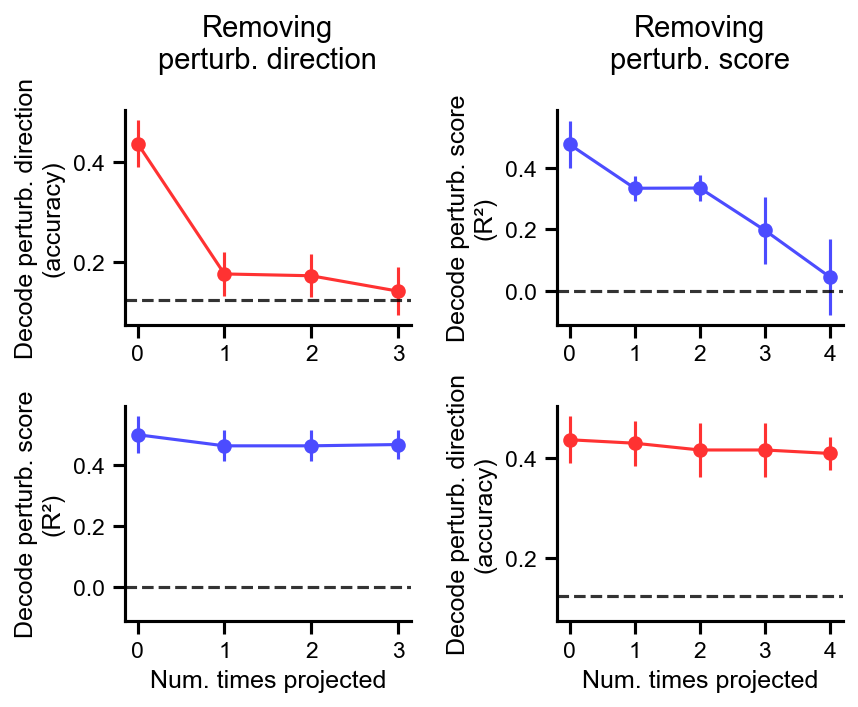

In [66]:
# ── Plot epoch iterative removal ─────────────────────────────────────────────
r  = epoch_results
it_dir  = r['iters_dir']
it_dist = r['iters_dist']
with rc_context_talk():

    fig, axs = plt.subplots(2, 2, figsize=(6, 5), sharey=None)

    # share y within same decode target (diagonal pairs)
    axs[0, 0].sharey(axs[1, 1])  # both decode direction (accuracy)
    axs[0, 1].sharey(axs[1, 0])  # both decode disturbance (R²)

    kw_err = dict(fmt='o-', capsize=0, lw=1.5, markersize=6)

    # ── Top-left: direction removal → direction ───────────────────────────────
    axs[0, 0].errorbar(it_dir, r['dir_rem_dir_m'],  yerr=r['dir_rem_dir_s'],
                    color=C_DIR, **kw_err)
    axs[0, 0].axhline(r['chance'], color='k', ls='--', lw=1.5, alpha=0.8, label=f'chance ({r["chance"]:.2f})')
    axs[0, 0].set_title('Removing\nperturb. direction', pad=20)
    axs[0, 0].set_ylabel('Decode perturb. direction\n(accuracy)')
    axs[0, 0].set_xticks(it_dir)
    # axs[0, 0].legend()

    # ── Top-right: disturbance removal → disturbance ──────────────────────────
    axs[0, 1].errorbar(it_dist, r['dist_rem_dist_m'], yerr=r['dist_rem_dist_s'],
                    color=C_DIST, **kw_err)
    axs[0, 1].axhline(0, color='k', ls='--', lw=1.5, alpha=0.8)
    axs[0, 1].set_title('Removing\nperturb. score', pad=20)
    axs[0, 1].set_xticks(it_dist)
    axs[0, 1].set_ylabel('Decode perturb. score\n(R²)')

    # axs[0, 1].legend()

    # ── Bottom-left: direction removal → disturbance ──────────────────────────
    axs[1, 0].errorbar(it_dir, r['dir_rem_dist_m'], yerr=r['dir_rem_dist_s'],
                    color=C_DIST, **kw_err)
    # axs[1, 0].errorbar(it_dir, r['dir_rem_lb_m'],   yerr=r['dir_rem_lb_s'],
    #                 color=C_DIST, alpha=0.4, fmt='o--', capsize=0, lw=1.5, markersize=4, label='lower bound')
    axs[1, 0].set_ylabel('Decode perturb. score\n(R²)')
    axs[1, 0].set_xticks(it_dir)
    axs[1, 0].axhline(0, color='k', ls='--', lw=1.5, alpha=0.8)

    # axs[1, 0].legend()
    axs[1, 0].set_xlabel('Num. times projected')

    # ── Bottom-right: disturbance removal → direction ─────────────────────────
    axs[1, 1].errorbar(it_dist, r['dist_rem_dir_m'],  yerr=r['dist_rem_dir_s'],
                    color=C_DIR, **kw_err)
    # axs[1, 1].errorbar(it_dist, r['dist_rem_lb_m'],   yerr=r['dist_rem_lb_s'],
    #                 color=C_DIST, alpha=0.4, fmt='o--', capsize=0, lw=1.5, markersize=4, label='lower bound')
    axs[1, 1].axhline(r['chance'], color='k', ls='--', lw=1.5, alpha=0.8, label=f'chance ({r["chance"]:.2f})')
    axs[1, 1].set_xticks(it_dist)
    axs[1, 1].set_ylabel('Decode perturb. direction\n(accuracy)')

    # axs[1, 1].legend()
    axs[1, 1].set_xlabel('Num. times projected')


    # plt.suptitle(f'{r["area"]} — Epoch avg : {r["epoch_s"]}s', fontsize=12)
    plt.tight_layout()
    plt.show()
    fig.savefig('../../results/pdfs/example_orthogonal_mop.svg', bbox_inches='tight')

Iter 0 (no removal): r=0.656, p=2.93e-37
Iter 6 (full removal): r=-0.067, p=0.252


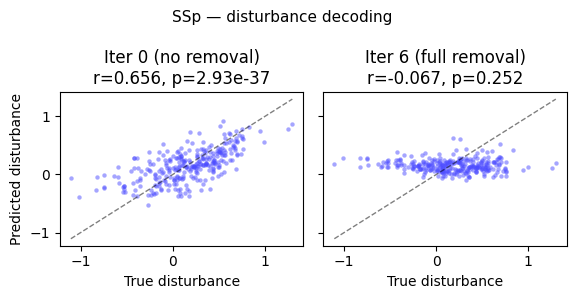

In [117]:
# ── Scatter: dist predictions — first vs last removal iteration ───────────────
from scipy.stats import pearsonr

r = epoch_results

fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey=True)

for ax, pred, true, title in zip(
    axs,
    [r['dist_first_pred'], r['dist_final_pred']],
    [r['dist_first_true'], r['dist_final_true']],
    ['Iter 0 (no removal)', f'Iter {r["max_iter_dist"]} (full removal)'],
):
    rho, pval = pearsonr(true, pred)
    ax.scatter(true, pred, s=10, alpha=0.5, color=C_DIST, linewidths=0)
    lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.5)
    ax.set_title(f'{title}\nr={rho:.3f}, p={pval:.3g}')
    ax.set_xlabel('True disturbance')
    print(f'{title}: r={rho:.3f}, p={pval:.3g}')

axs[0].set_ylabel('Predicted disturbance')
plt.suptitle(f'{r["area"]} — disturbance decoding', fontsize=11)
plt.tight_layout()
plt.show()

# Multi area epoch-averaged removal

In [117]:
# ── Epoch-average iterative removal — all areas ───────────────────────────────
# Incremental strategy throughout. Iteration counts are exposed per area
# and per removal condition.

epoch_s     = np.array([0, 0.5])
epoch_bins  = (epoch_s / 0.01 + 200).astype(int)
n_splits    = 4
alpha_ridge = 0.01

pc_dict = {'MOp': 30, 'SSp': 25, 'CP': 30, 'VAL': 50}

# ── Iteration counts per area and condition ───────────────────────────────────
max_iter_dir_by_area  = {'MOp': 4, 'SSp': 2, 'CP': 3, 'VAL': 3}
max_iter_dist_by_area = {'MOp': 4, 'SSp': 1, 'CP': 3, 'VAL': 1}

y_dir    = np.array(td_drop.values_Sol_direction.values.tolist())
y_dist   = td_drop.disturb_sum.values.astype(float)
y_shuf_t = np.random.default_rng(42).permutation(y_dist)

_, _counts = np.unique(y_dir, return_counts=True)
chance = _counts.max() / _counts.sum()

cv_dir  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_dist = KFold(n_splits=n_splits, shuffle=True, random_state=42)


def _decode_epoch(X_d, N):
    d_dir = [
        LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
        .fit(X_d[tr], y_dir[tr]).score(X_d[te], y_dir[te])
        for tr, te in cv_dir.split(X_d, y_dir)
    ]
    d_dist, d_lb = [], []
    for tr, te in cv_dist.split(X_d):
        reg = Ridge(alpha_ridge).fit(X_d[tr], y_dist[tr])
        d_dist.append(r2_score(y_dist[te],   reg.predict(X_d[te])))
        d_lb.append(  r2_score(y_shuf_t[te], reg.predict(X_d[te])))
    return d_dir, d_dist, d_lb


epoch_results_all = {}

for area in pc_dict:
    N             = pc_dict[area]
    max_iter_dir  = max_iter_dir_by_area[area]
    max_iter_dist = max_iter_dist_by_area[area]

    X_full_a = np.stack(td_drop[f'{area}_rates_pca'].values)[:, :, :N]
    X_epoch  = X_full_a[:, epoch_bins[0]:epoch_bins[1], :].mean(axis=1)

    # ── Direction removal ─────────────────────────────────────────────────────
    dir_rem_dir_folds, dir_rem_dist_folds, dir_rem_lb_folds = [], [], []
    X_d = X_epoch.copy()
    for n_rem in range(max_iter_dir + 1):
        d_dir, d_dist, d_lb = _decode_epoch(X_d, N)
        dir_rem_dir_folds.append(d_dir)
        dir_rem_dist_folds.append(d_dist)
        dir_rem_lb_folds.append(d_lb)
        if n_rem < max_iter_dir:
            ax  = get_lda_axes(X_d, y_dir)
            X_d = X_d @ (np.eye(N) - ax @ ax.T)

    # ── Disturbance removal ───────────────────────────────────────────────────
    dist_rem_dir_folds, dist_rem_dist_folds, dist_rem_lb_folds = [], [], []
    X_d = X_epoch.copy()
    for n_rem in range(max_iter_dist + 1):
        d_dir, d_dist, d_lb = _decode_epoch(X_d, N)
        dist_rem_dir_folds.append(d_dir)
        dist_rem_dist_folds.append(d_dist)
        dist_rem_lb_folds.append(d_lb)
        if n_rem < max_iter_dist:
            ax  = get_ridge_axis(X_d, y_dist, alpha=alpha_ridge)
            X_d = X_d @ (np.eye(N) - ax @ ax.T)

    iters_dir  = np.arange(max_iter_dir  + 1)
    iters_dist = np.arange(max_iter_dist + 1)

    epoch_results_all[area] = dict(
        area=area, epoch_s=epoch_s, chance=chance,
        max_iter_dir=max_iter_dir,   iters_dir=iters_dir,
        max_iter_dist=max_iter_dist, iters_dist=iters_dist,
        dir_rem_dir_m=np.array([np.mean(f) for f in dir_rem_dir_folds]),
        dir_rem_dir_s=np.array([np.std(f)  for f in dir_rem_dir_folds]),
        dir_rem_dist_m=np.array([np.mean(f) for f in dir_rem_dist_folds]),
        dir_rem_dist_s=np.array([np.std(f)  for f in dir_rem_dist_folds]),
        dir_rem_lb_m=np.array([np.mean(f) for f in dir_rem_lb_folds]),
        dir_rem_lb_s=np.array([np.std(f)  for f in dir_rem_lb_folds]),
        dist_rem_dir_m=np.array([np.mean(f) for f in dist_rem_dir_folds]),
        dist_rem_dir_s=np.array([np.std(f)  for f in dist_rem_dir_folds]),
        dist_rem_dist_m=np.array([np.mean(f) for f in dist_rem_dist_folds]),
        dist_rem_dist_s=np.array([np.std(f)  for f in dist_rem_dist_folds]),
        dist_rem_lb_m=np.array([np.mean(f) for f in dist_rem_lb_folds]),
        dist_rem_lb_s=np.array([np.std(f)  for f in dist_rem_lb_folds]),
        dir_rem_dir_folds=dir_rem_dir_folds,     dir_rem_dist_folds=dir_rem_dist_folds,
        dir_rem_lb_folds=dir_rem_lb_folds,       dist_rem_dir_folds=dist_rem_dir_folds,
        dist_rem_dist_folds=dist_rem_dist_folds, dist_rem_lb_folds=dist_rem_lb_folds,
    )

    r = epoch_results_all[area]
    print(f'{area}  Epoch avg: {epoch_s}s  (dir iters: {max_iter_dir}, dist iters: {max_iter_dist})')
    print(f'  dir-rem  → dir:  {[f"{v:.3f}" for v in r["dir_rem_dir_m"]]}')
    print(f'  dir-rem  → dist: {[f"{v:.3f}" for v in r["dir_rem_dist_m"]]}')
    print(f'  dist-rem → dir:  {[f"{v:.3f}" for v in r["dist_rem_dir_m"]]}')
    print(f'  dist-rem → dist: {[f"{v:.3f}" for v in r["dist_rem_dist_m"]]}')


MOp  Epoch avg: [0.  0.5]s  (dir iters: 4, dist iters: 4)
  dir-rem  → dir:  ['0.349', '0.127', '0.086', '0.086', '0.063']
  dir-rem  → dist: ['0.471', '0.512', '0.513', '0.515', '0.514']
  dist-rem → dir:  ['0.349', '0.349', '0.367', '0.371', '0.321']
  dist-rem → dist: ['0.471', '0.259', '0.259', '0.148', '-0.033']
SSp  Epoch avg: [0.  0.5]s  (dir iters: 2, dist iters: 1)
  dir-rem  → dir:  ['0.203', '0.059', '0.063']
  dir-rem  → dist: ['0.204', '0.085', '0.085']
  dist-rem → dir:  ['0.203', '0.204']
  dist-rem → dist: ['0.204', '-0.025']
CP  Epoch avg: [0.  0.5]s  (dir iters: 3, dist iters: 3)
  dir-rem  → dir:  ['0.235', '0.095', '0.086', '0.086']
  dir-rem  → dist: ['0.434', '0.374', '0.374', '0.375']
  dist-rem → dir:  ['0.235', '0.244', '0.231', '0.235']
  dist-rem → dist: ['0.434', '0.117', '0.117', '-0.007']
VAL  Epoch avg: [0.  0.5]s  (dir iters: 3, dist iters: 1)
  dir-rem  → dir:  ['0.262', '0.077', '0.027', '0.023']
  dir-rem  → dist: ['0.279', '0.239', '0.239', '0.260']


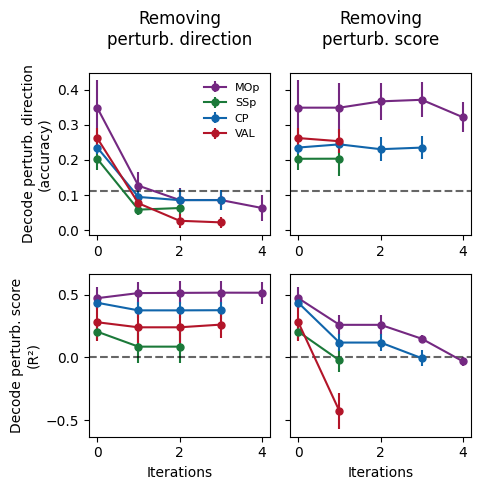

In [118]:
# ── Plot: epoch iterative removal — all areas ─────────────────────────────────
area_colors = {
    'MOp': colors.MOp,
    'SSp': colors.SSp,
    'CP':  colors.CP,
    'VAL': colors.VAL,
}

kw_err = dict(fmt='o-', capsize=0, lw=1.5, markersize=5)
kw_lb  = dict(fmt='o--', capsize=0, lw=1.5, markersize=4, alpha=0.4)

# with rc_context_talk():
fig, axs = plt.subplots(2, 2, figsize=(5, 5), sharey='row')

for area, r in epoch_results_all.items():
    c        = area_colors[area]
    it_dir   = r['iters_dir']
    it_dist  = r['iters_dist']

    # ── Top-left: direction removal → direction ───────────────────────────
    axs[0, 0].errorbar(it_dir, r['dir_rem_dir_m'], yerr=r['dir_rem_dir_s'],
                        color=c, label=area, **kw_err)

    # ── Top-right: disturbance removal → direction ────────────────────────
    axs[0, 1].errorbar(it_dist, r['dist_rem_dir_m'], yerr=r['dist_rem_dir_s'],
                        color=c, label=area, **kw_err)

    # ── Bottom-left: direction removal → disturbance ──────────────────────
    axs[1, 0].errorbar(it_dir, r['dir_rem_dist_m'], yerr=r['dir_rem_dist_s'],
                        color=c, **kw_err)
    # axs[1, 0].errorbar(it_dir, r['dir_rem_lb_m'], yerr=r['dir_rem_lb_s'],
    #                     color=c, **kw_lb)

    # ── Bottom-right: disturbance removal → disturbance ───────────────────
    axs[1, 1].errorbar(it_dist, r['dist_rem_dist_m'], yerr=r['dist_rem_dist_s'],
                        color=c, **kw_err)
    # axs[1, 1].errorbar(it_dist, r['dist_rem_lb_m'], yerr=r['dist_rem_lb_s'],
    #                     color=c, **kw_lb)

# chance line on direction panels (same for all areas)
chance = next(iter(epoch_results_all.values()))['chance']
axs[0, 0].axhline(chance, color='k', ls='--', lw=1.5, alpha=0.6)
axs[0, 1].axhline(chance, color='k', ls='--', lw=1.5, alpha=0.6)

axs[0, 0].set_title('Removing\nperturb. direction', pad=20)
axs[0, 1].set_title('Removing\nperturb. score', pad=20)
axs[1, 0].axhline(0, color='k', ls='--', lw=1.5, alpha=0.6)
axs[1, 1].axhline(0, color='k', ls='--', lw=1.5, alpha=0.6)

axs[0, 0].set_ylabel('Decode perturb. direction\n(accuracy)')
axs[1, 0].set_ylabel('Decode perturb. score\n(R²)')
axs[1, 0].set_xlabel('Iterations')
axs[1, 1].set_xlabel('Iterations')

axs[0, 0].legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()


In [119]:
# ── Convergence scores — all areas ────────────────────────────────────────────
# Updated norm_residual functions clip negative values to 0:
# scores below the lower bound are trivially destroyed and noise-driven.

def norm_residual(scores, lb):
    """Normalised residual: 0 = destroyed, 1 = preserved. Clipped at 0."""
    s0  = np.mean(scores[0])
    sf  = np.mean(scores[-1])
    lb0 = np.mean(lb[0]) if isinstance(lb, list) else lb
    denom = s0 - lb0
    if denom < 1e-9:
        return np.nan
    return max((sf - lb0) / denom, 0.0)


def norm_residual_folds(scores, lb):
    """Per-fold normalised residuals. Clipped at 0."""
    s0_folds = np.array(scores[0])
    sf_folds = np.array(scores[-1])
    lb0_mean = np.mean(lb[0]) if isinstance(lb, list) else lb
    denom    = np.mean(s0_folds) - lb0_mean
    if denom < 1e-9:
        return np.full(len(s0_folds), np.nan)
    return np.maximum((sf_folds - lb0_mean) / denom, 0.0)


# ── Compute per-area ──────────────────────────────────────────────────────────
convergence_all = {}

for area, r in epoch_results_all.items():
    chance = r['chance']

    # direction lb = chance level; disturbance lb = shuffled-label folds
    conv = dict(
        dir_after_dir_rem  = norm_residual(r['dir_rem_dir_folds'],  chance),
        dist_after_dir_rem = norm_residual(r['dir_rem_dist_folds'],  0),
        dir_after_dist_rem = norm_residual(r['dist_rem_dir_folds'], chance),
        dist_after_dist_rem= norm_residual(r['dist_rem_dist_folds'], 0),
        dir_after_dir_rem_folds  = norm_residual_folds(r['dir_rem_dir_folds'],  chance),
        dist_after_dir_rem_folds = norm_residual_folds(r['dir_rem_dist_folds'],  0),
        dir_after_dist_rem_folds = norm_residual_folds(r['dist_rem_dir_folds'], chance),
        dist_after_dist_rem_folds= norm_residual_folds(r['dist_rem_dist_folds'], 0),
    )
    convergence_all[area] = conv

# ── Print summary table ───────────────────────────────────────────────────────
# Columns: dir|dir-rem, dist|dir-rem, dir|dist-rem, dist|dist-rem
# Expected: ~0,         ~1,           ~1,           ~0

col_w = 20
header = f"{'Area':>5}  {'dir|dir-rem':>{col_w}}  {'dist|dir-rem':>{col_w}}  {'dir|dist-rem':>{col_w}}  {'dist|dist-rem':>{col_w}}"
sep    = '-' * len(header)
note   = '(expect ~0)          (expect ~1)          (expect ~1)          (expect ~0)'

print(f"Convergence scores  (~0 = destroyed, ~1 = preserved, clipped at 0)")
print(f"{'':>7}{note}")
print(sep)
print(header)
print(sep)

for area, conv in convergence_all.items():
    def fmt(key):
        m = conv[key]
        s = np.std(conv[key + '_folds'])
        return f'{m:.2f} ± {s:.2f}'
    print(f"{area:>5}  "
          f"{fmt('dir_after_dir_rem'):>{col_w}}  "
          f"{fmt('dist_after_dir_rem'):>{col_w}}  "
          f"{fmt('dir_after_dist_rem'):>{col_w}}  "
          f"{fmt('dist_after_dist_rem'):>{col_w}}")


Convergence scores  (~0 = destroyed, ~1 = preserved, clipped at 0)
       (expect ~0)          (expect ~1)          (expect ~1)          (expect ~0)
---------------------------------------------------------------------------------------------
 Area           dir|dir-rem          dist|dir-rem          dir|dist-rem         dist|dist-rem
---------------------------------------------------------------------------------------------
  MOp           0.00 ± 0.03           1.09 ± 0.19           0.88 ± 0.18           0.00 ± 0.02
  SSp           0.00 ± 0.00           0.42 ± 0.47           1.00 ± 0.54           0.00 ± 0.25
   CP           0.00 ± 0.00           0.86 ± 0.16           1.00 ± 0.27           0.00 ± 0.08
  VAL           0.00 ± 0.00           0.93 ± 0.39           0.94 ± 0.22           0.00 ± 0.00


In [120]:
# ── Save convergence results ──────────────────────────────────────────────────
# Accumulates results across sessions in a single pkl keyed by session name.
# Run this cell after processing each session to build up the file.

import pickle
from pathlib import Path

results_path = Path('../../results/convergence/potent_null_convergence_v2.pkl')
session      = SESSIONS[0]

# Load existing file if present, otherwise start fresh
if results_path.exists():
    with open(results_path, 'rb') as f:
        all_sessions = pickle.load(f)
    print(f'Loaded existing file with {len(all_sessions)} session(s): {list(all_sessions.keys())}')
else:
    all_sessions = {}
    print('Starting new results file.')

# Store this session
all_sessions[session] = convergence_all

with open(results_path, 'wb') as f:
    pickle.dump(all_sessions, f)

print(f"Saved session '{session}'. File now contains {len(all_sessions)} session(s):")
for s in all_sessions:
    marker = ' ← current' if s == session else ''
    print(f'  {s}{marker}')


Loaded existing file with 3 session(s): ['M103_2026_02_18_15_30', 'M106_2026_02_25_15_00', 'M078_2025_08_06_15_00']
Saved session 'M061_2025_03_06_14_00'. File now contains 4 session(s):
  M103_2026_02_18_15_30
  M106_2026_02_25_15_00
  M078_2025_08_06_15_00
  M061_2025_03_06_14_00 ← current


Loaded 4 session(s): ['M106_2026_02_25_15_00', 'M103_2026_02_18_15_30', 'M061_2025_03_06_14_00', 'M078_2025_08_06_15_00']


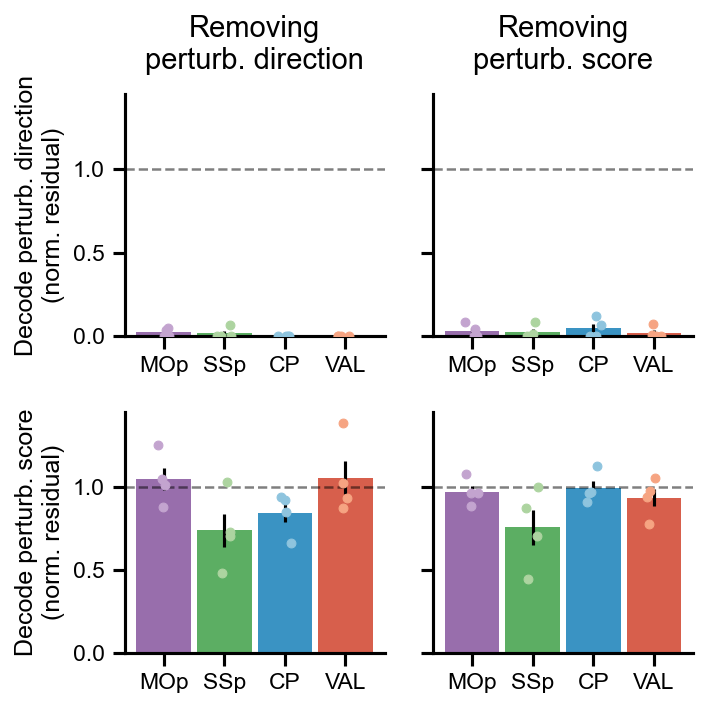

In [123]:
# ── Plot convergence results — bar chart ──────────────────────────────────────
# Columns = removal type, rows = decoded variable.
# Session values overlaid as dots.

import pickle
from pathlib import Path

results_path = Path('../../results/convergence/potent_null_convergence.pkl')

with open(results_path, 'rb') as f:
    all_sessions = pickle.load(f)

print(f'Loaded {len(all_sessions)} session(s): {list(all_sessions.keys())}')

areas       = ['MOp', 'SSp', 'CP', 'VAL']
area_colors = [colors.MOp_light, colors.SSp_light, colors.CP_light, colors.VAL_light]
area_colors_light = [colors.MOp_light_light, colors.SSp_light_light, colors.CP_light_light, colors.VAL_light_light]

n_sessions  = len(all_sessions)

# (key, folds_key) arranged as: rows = decoded var, cols = removal type
#           col0: dir removal          col1: dist removal
panels = [
    [('dir_after_dir_rem',   'dir_after_dir_rem_folds'),    # row0, col0
     ('dist_after_dist_rem', 'dist_after_dist_rem_folds')], # row0, col1  (swapped)
    [('dist_after_dir_rem',  'dist_after_dir_rem_folds'),   # row1, col0
     ('dir_after_dist_rem',  'dir_after_dist_rem_folds')],  # row1, col1  (swapped)
]

col_titles = ['Removing\nperturb. direction', 'Removing\nperturb. score']
row_labels = ['Decode perturb. direction\n(norm. residual)',
              'Decode perturb. score\n(norm. residual)']

x     = np.arange(len(areas))
width = 0.9
rng   = np.random.default_rng(0)

def session_vals(key, area):
    return [s[area][key] for s in all_sessions.values() if area in s]

with rc_context_talk():
    fig, axs = plt.subplots(2, 2, figsize=(5, 5), sharey=True)

    for row, row_panels in enumerate(panels):
        for col, (key, folds_key) in enumerate(row_panels):
            ax = axs[row, col]

            means = [np.mean(session_vals(key, a)) for a in areas]
            errs  = [np.std(session_vals(key, a)) / np.sqrt(max(len(session_vals(key, a)), 1))
                     for a in areas]

            # bars
            ax.bar(x, means, width, color=area_colors, zorder=2)
            ax.errorbar(x, means, yerr=errs, fmt='none', color='k',
                        capsize=0, lw=1.5, zorder=3)

            # session dots
            jitter = rng.uniform(-0.12, 0.12, size=(n_sessions, len(areas)))
            for si, sess_data in enumerate(all_sessions.values()):
                vals = [sess_data[a][key] for a in areas]
                for xi, (v, c) in enumerate(zip(vals, area_colors_light)):
                    ax.scatter(xi + jitter[si, xi], v, color=c, s=18,
                               zorder=4, alpha=1, linewidths=0.5)

            ax.axhline(1.0, color='k', ls='--', lw=1.2, alpha=0.5)
            ax.axhline(0.0, color='k', ls='--', lw=1.2, alpha=0.2)
            ax.set_xticks(x)
            ax.set_xticklabels(areas)
            # ax.set_ylim(bottom=min(-0.05, min(m - e for m, e in zip(means, errs)) - 0.05))

            if row == 0:
                ax.set_title(col_titles[col], pad=12)
            if col == 0:
                ax.set_ylabel(row_labels[row])

    plt.tight_layout()
    plt.show()
    fig.savefig('../../results/pdfs/orthogonal_all_areas_4_animals.svg', bbox_inches='tight')

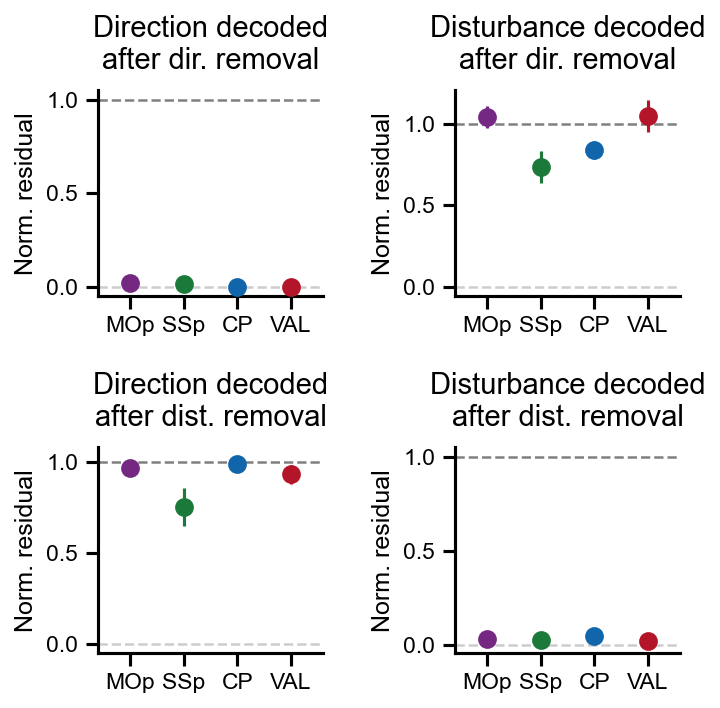

In [70]:
# ── Plot convergence results — dot + error bar ────────────────────────────────
panels = [
    ('dir_after_dir_rem',   'dir_after_dir_rem_folds',   'Direction decoded\nafter dir. removal'),
    ('dist_after_dir_rem',  'dist_after_dir_rem_folds',  'Disturbance decoded\nafter dir. removal'),
    ('dir_after_dist_rem',  'dir_after_dist_rem_folds',  'Direction decoded\nafter dist. removal'),
    ('dist_after_dist_rem', 'dist_after_dist_rem_folds', 'Disturbance decoded\nafter dist. removal'),
]

x = np.arange(len(areas))

with rc_context_talk():
    fig, axs = plt.subplots(2, 2, figsize=(5, 5), sharey=False)

    for ax, (key, folds_key, title) in zip(axs.flat, panels):
        means = [get_mean_err(key, folds_key, a)[0] for a in areas]
        errs  = [get_mean_err(key, folds_key, a)[1] for a in areas]

        for xi, (m, e, c) in enumerate(zip(means, errs, area_colors)):
            ax.errorbar(xi, m, yerr=e, fmt='o', color=c,
                        markersize=8, lw=1.5, capsize=0, zorder=3)

        ax.axhline(1.0, color='k', ls='--', lw=1.2, alpha=0.5)
        ax.axhline(0.0, color='k', ls='--', lw=1.2, alpha=0.2)
        ax.set_xticks(x)
        ax.set_xticklabels(areas)
        ax.set_ylabel('Norm. residual')
        ax.set_title(title, pad=10)
        ax.set_xlim(-0.6, len(areas) - 0.4)

    plt.tight_layout()
    plt.show()
